# Gender Detection from Face Images using a CNN
### Binary image classification with MobileNetV2 transfer learning (TensorFlow / Keras)

**Objective:** Build a convolutional neural network that classifies a face image as **man** or **woman**.

**Approach:** Transfer learning. A MobileNetV2 backbone pre-trained on ImageNet is kept frozen and used as a feature extractor, with a small trainable classification head on top. Training was done on Google Colab (GPU runtime).

**Stack:** Python, TensorFlow 2.20.0, Keras, scikit-learn, pandas, matplotlib, seaborn, PIL.

---

## Results at a glance

| Item | Value |
|---|---|
| Dataset size | 2,307 images (1,173 man, 1,134 woman) |
| Split (stratified, seed 42) | 1,614 train / 346 validation / 347 test |
| Input size | 224 x 224 x 3 |
| Total / trainable parameters | 2,586,177 / 328,193 |
| Epochs run | 19 (maximum 40, stopped by early stopping) |
| Best epoch | 9 (validation loss 0.1056, validation accuracy 96.24%) |
| **Test accuracy** | **94.81%** |
| Test loss | 0.1483 |
| Macro F1-score | 0.95 |
| Misclassified test images | 18 out of 347 |

---

## Notebook outline

1. Environment setup
2. Data exploration (EDA)
3. Data preparation (labels and train / validation / test split)
4. Input pipeline with `tf.data`
5. Data augmentation
6. Model architecture
7. Training
8. Evaluation and error analysis
9. Single image inference
10. Conclusion, limitations and future work

---
# 1. Environment Setup

## 1.1 Imports and hardware check

**What this cell does:** Imports the libraries used throughout the notebook (NumPy / pandas for data handling, matplotlib / seaborn for plots, PIL for image reading, TensorFlow / Keras for the model, scikit-learn for splitting and metrics). It then prints the TensorFlow version and the GPUs TensorFlow can see.

**Why:** Training a CNN on CPU is slow, so it is worth confirming up front that a GPU is available. Printing the version also makes the run reproducible.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


> **Observation:** TensorFlow 2.20.0 is installed and one GPU (`GPU:0`) is detected, so training runs on GPU.

## 1.2 Mount Google Drive

**What this cell does:** Mounts Google Drive inside the Colab runtime.

**Why:** The dataset is stored on Drive as a zip file, so Colab needs access to that storage.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> **Observation:** Drive mounted successfully at `/content/drive`.

## 1.3 Locate and extract the dataset

**What these cells do:** Store the zip path in `zip_path`, then extract the archive to `/content/genderdetc_dataset` on the Colab local disk.

**Why:** Reading thousands of small image files directly from a mounted Drive is generally slower than reading them from the runtime's local disk, so the archive is unpacked locally once.

In [3]:
zip_path = "/content/drive/MyDrive/PRAICP-1001-GenderDetc.zip"

In [4]:
import zipfile
import os

extract_path = "/content/genderdetc_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/genderdetc_dataset


> **Observation:** The dataset was extracted without errors to `/content/genderdetc_dataset`.

---
# 2. Data Exploration (EDA)

Before building anything, the dataset is checked for structure, class balance, file integrity and image size variation. These checks decide which preprocessing steps are needed later.

## 2.1 Inspect the dataset directory

**What this cell does:** Lists the sub-folders inside the dataset directory.

**Why:** The data follows a one-folder-per-class layout, so each folder name becomes a class label. Listing the folders confirms the classes before any label mapping is built.

In [5]:
dataset_dir = "/content/genderdetc_dataset/Data/gender_dataset_face"
classes = sorted(os.listdir(dataset_dir))

print("Number of classes:", len(classes))
print("classes:",classes)

Number of classes: 2
classes: ['man', 'woman']


> **Observation:** There are **2 classes**: `man` and `woman`. This is a binary classification problem.

## 2.2 Count images per class

**What this cell does:** Keeps only folders that actually contain image files (`.jpg`, `.jpeg`, `.png`, `.bmp`, `.webp`), counts the images in each, and stores the counts in the DataFrame `class_counts_df`.

**Why:** Class counts show whether the dataset is balanced, which affects the choice of metrics and whether class weighting or resampling would be needed.

In [6]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Get only folders containing images
classes = []

for cls in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, cls)

    # Check if it is a folder
    if os.path.isdir(class_path):

        # Check if folder contains at least one image
        has_image = any(
            file.lower().endswith(image_extensions)
            for file in os.listdir(class_path)
        )

        if has_image:
            classes.append(cls)

# Sort classes
classes = sorted(classes)

print("Number of valid classes:", len(classes))
print("First 10 classes:", classes)


# Count images in each valid class
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count


# Create DataFrame
class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["gender", "Image_Count"]
)

class_counts_df.head()

Number of valid classes: 2
First 10 classes: ['man', 'woman']


,gender,Image_Count
0,man,1173
1,woman,1134


> **Observation:**
>
> | Class | Images |
> |---|---|
> | man | 1,173 |
> | woman | 1,134 |

## 2.3 Dataset statistics

**What this cell does:** Prints total image count, number of classes, and the minimum, maximum and average images per class.

**Why:** A compact numeric summary of dataset size and balance.

In [7]:
print("Total images:", class_counts_df["Image_Count"].sum())
print("Number of genders:", len(class_counts_df))
print("Minimum images:", class_counts_df["Image_Count"].min())
print("Maximum images:", class_counts_df["Image_Count"].max())
print("Average images:", class_counts_df["Image_Count"].mean())

Total images: 2307
Number of genders: 2
Minimum images: 1134
Maximum images: 1173
Average images: 1153.5


> **Observation:** 2,307 images in total across 2 classes (minimum 1,134, maximum 1,173, average 1,153.5).
>
> **Conclusion:** The two classes differ by only 39 images, so the dataset is effectively balanced. No class weighting or resampling is needed, and accuracy is a meaningful metric here.

## 2.4 Check for corrupted images

**What this cell does:** Opens every image and calls PIL's `verify()`. Any file that raises an error is collected in `corrupted_images`.

**Why:** A single unreadable file would crash the `tf.data` pipeline in the middle of training. It is cheaper to find such files up front.

In [8]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for path in corrupted_images[:10]:
        print(path)

Corrupted images: 0


> **Observation:** **0 corrupted images** were found.
>
> **Conclusion:** No cleaning or file removal is required.

## 2.5 Class distribution plot

**What this cell does:** Plots the number of images per class as a bar chart.

**Why:** A visual check of the balance found in Section 2.3.

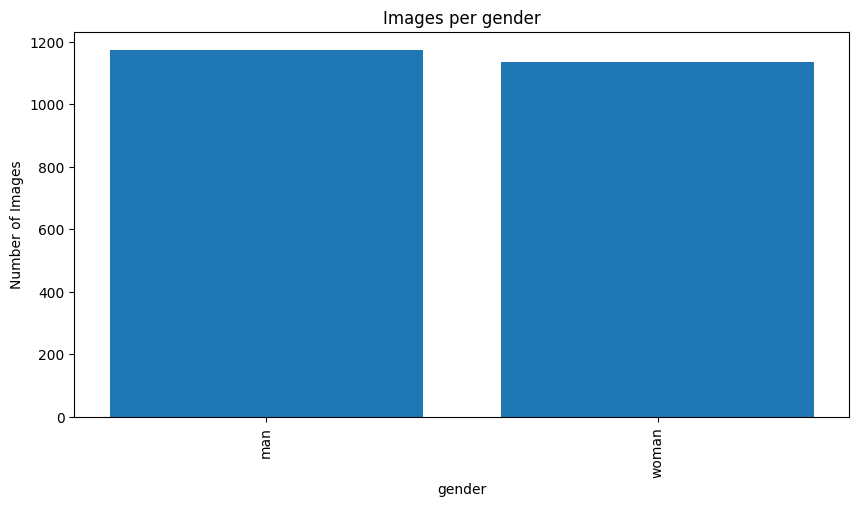

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts_df["gender"],
    class_counts_df["Image_Count"]
)

plt.xticks(rotation=90)
plt.xlabel("gender")
plt.ylabel("Number of Images")
plt.title("Images per gender")

plt.show()

> **Observation:** The two bars are almost the same height (about 1,170 for `man` and 1,130 for `woman`), matching the counts above.

## 2.6 Visualise random samples

**What this cell does:** Draws 12 random images from random classes and shows the class name above each.

**Why:** Numbers cannot tell us whether the images look right. This check confirms that the folder labels match the image content and shows how much natural variation the model will have to handle. The selection is not seeded, so the grid changes each time the cell is run.

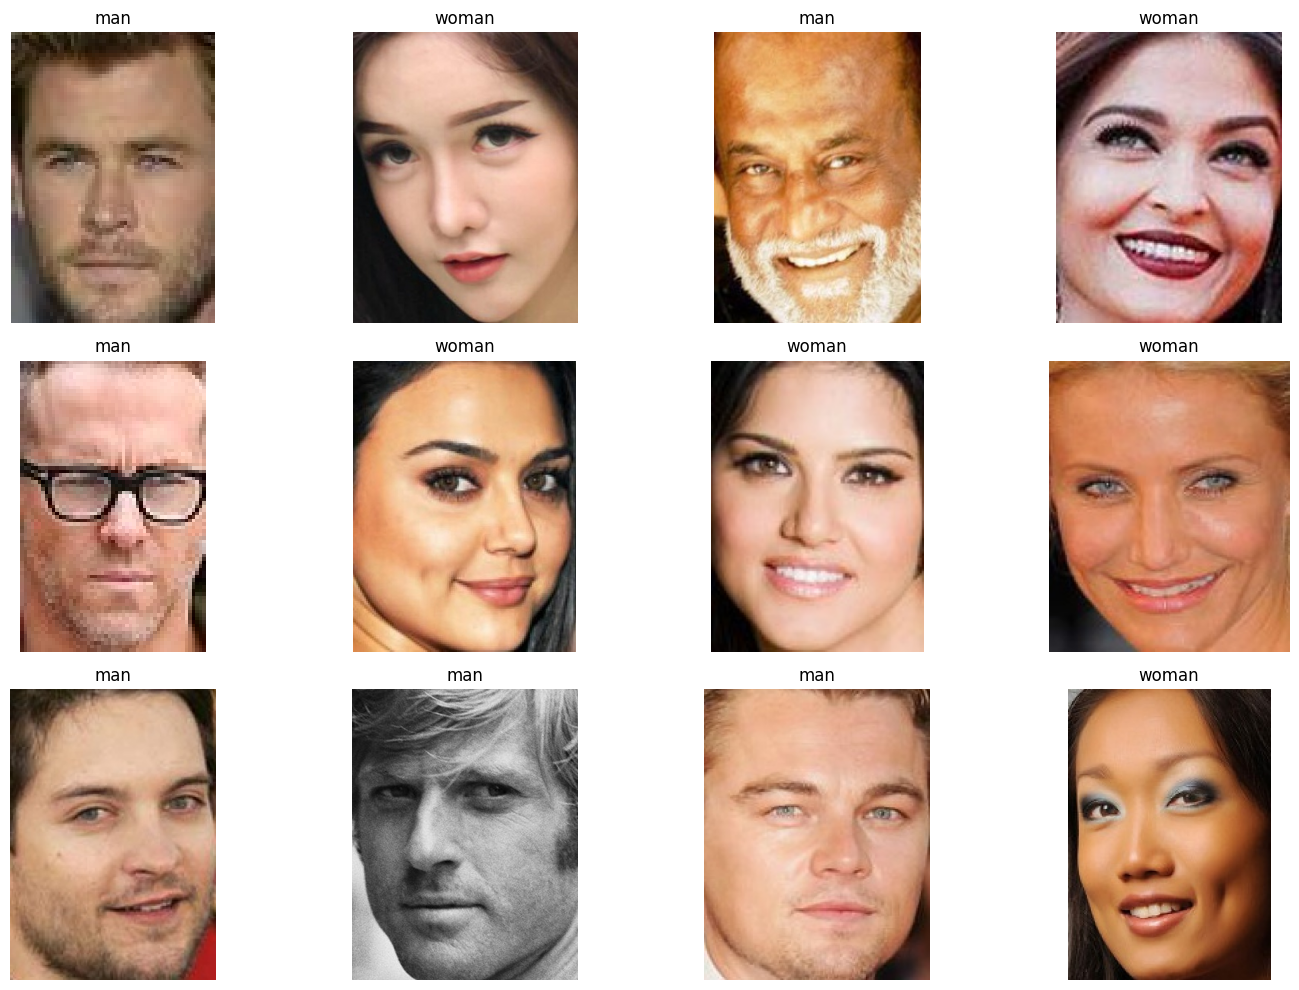

In [10]:
import random
from PIL import Image

plt.figure(figsize=(15, 10))

for i in range(12):
    gender = random.choice(classes)
    gender_path = os.path.join(dataset_dir, gender)

    images = [
        f for f in os.listdir(gender_path)
        if f.lower().endswith(image_extensions)
    ]

    image_name = random.choice(images)
    image_path = os.path.join(gender_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(gender)
    plt.axis("off")

plt.tight_layout()
plt.show()

> **Observation:** The images are face-focused crops with a lot of natural variation in age, pose, lighting, expression and image quality. At least one sample is grayscale, and the crops have different shapes and aspect ratios.
>
> **Conclusion:** Images must be converted to 3-channel RGB and resized to one fixed shape, and augmentation should help the model cope with pose and lighting variation.

## 2.7 Image size analysis

**What this cell does:** Reads the width and height of the first 20 images of each class (40 images in total) and summarises them with `describe()`.

**Why:** A CNN needs a fixed input size. Knowing the range of original sizes tells us how much resizing is involved. Only a sample is read here to keep the check fast.

In [11]:
sizes = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    for image_name in images[:20]:
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)
        except:
            pass

sizes_df = pd.DataFrame(sizes, columns=["Width", "Height"])

sizes_df.describe()

,Width,Height
count,40.000000,40.000000
mean,206.000000,262.750000
std,143.007441,168.890611
min,51.000000,65.000000
25%,115.750000,160.000000
50%,157.000000,209.500000
75%,272.500000,330.250000
max,683.000000,822.000000


> **Observation (based on the 40 sampled images):**
>
> | | Width (px) | Height (px) |
> |---|---|---|
> | Mean | 206.0 | 262.8 |
> | Median | 157.0 | 209.5 |
> | Min | 51 | 65 |
> | Max | 683 | 822 |
> | Std | 143.0 | 168.9 |
>
> **Conclusion:** Image sizes vary widely, and images are on average taller than wide. All images therefore have to be resized to a common shape (224 x 224 is used, see Section 4). Since this is a 40-image sample, the exact figures are indicative rather than exact for the full dataset.

## 2.8 EDA summary

- 2,307 images, 2 classes, effectively balanced (1,173 vs 1,134).
- No corrupted files.
- Large variation in image size, pose, lighting and quality.
- Next steps: build a labelled DataFrame, split the data, and create a resize + normalise pipeline.

---
# 3. Data Preparation

## 3.1 Build a DataFrame of image paths and labels

**What this cell does:** Walks through each class folder and creates one row per image with two columns: `image_path` and `gender`.

**Why:** A table of paths and labels makes it easy to split the data with scikit-learn and to feed the paths into `tf.data` later, without loading any image into memory yet.

In [12]:
import os
import pandas as pd

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

data = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for file in os.listdir(class_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file)

            data.append({
                "image_path": image_path,
                "gender": cls
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["gender"].nunique())

df.head()

Total images: 2307
Total classes: 2


,image_path,gender
0,/content/genderdetc_dataset/Data/gender_datase...,man
1,/content/genderdetc_dataset/Data/gender_datase...,man
2,/content/genderdetc_dataset/Data/gender_datase...,man
3,/content/genderdetc_dataset/Data/gender_datase...,man
4,/content/genderdetc_dataset/Data/gender_datase...,man


> **Observation:** The DataFrame holds **2,307 rows** and **2 unique classes**, which matches the counts from the EDA section.

## 3.2 Encode the class labels

**What this cell does:** Builds two dictionaries from the sorted class names: `class_to_index` (name to number) and `index_to_class` (number to name).

**Why:** Neural networks need numeric targets. Because this is a binary problem with a single sigmoid output unit and binary cross-entropy loss, the labels must be 0 and 1.

In [13]:
classes = sorted(df["gender"].unique())

class_to_index = {
    gender: index
    for index, gender in enumerate(classes)
}

index_to_class = {
    index: gender
    for gender, index in class_to_index.items()
}

### 3.2.1 Verify the mapping

In [14]:
print("Number of classes:", len(classes))

print("\n mappings:")
for i in range(len(classes)):
    print(i, "→", index_to_class[i])

Number of classes: 2

 mappings:
0 → man
1 → woman


> **Observation:** `man` is mapped to **0** and `woman` to **1** (alphabetical order). The model's sigmoid output will therefore represent the probability of **woman**.

### 3.2.2 Add the numeric label column

**What these cells do:** Map the class names in the DataFrame to their integer index and preview the result.

In [15]:
df["label"] = df["gender"].map(class_to_index)

In [16]:
df.head()

,image_path,gender,label
0,/content/genderdetc_dataset/Data/gender_datase...,man,0
1,/content/genderdetc_dataset/Data/gender_datase...,man,0
2,/content/genderdetc_dataset/Data/gender_datase...,man,0
3,/content/genderdetc_dataset/Data/gender_datase...,man,0
4,/content/genderdetc_dataset/Data/gender_datase...,man,0


> **Observation:** The DataFrame now has a `label` column (0 for `man`, 1 for `woman`) next to the image path and class name.

## 3.3 Train / validation / test split

**What this cell does:** Splits the data in two steps. First 70% goes to training and 30% to a temporary set. That temporary set is then split 50 / 50 into validation and test, giving roughly **70% / 15% / 15%**.

**Why each choice matters:**
- **Three sets:** training data fits the weights, validation data is used for early stopping and model selection, and the test set stays untouched until the final evaluation so that it gives an unbiased estimate.
- **`stratify=label`:** keeps the man / woman ratio the same in every split.
- **`random_state=42`:** makes the split reproducible.

In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [18]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 1614
Validation: 346
Testing: 347


> **Observation:**
>
> | Split | Images |
> |---|---|
> | Training | 1,614 |
> | Validation | 346 |
> | Test | 347 |
>
> The three sets add up to 2,307, the full dataset.

## 3.4 Sanity checks on the splits

**What these cells do:** Count the unique classes in each split, then preview the first 10 training rows.

**Why:** To confirm that both classes are present in every split and that the rows are shuffled.

In [19]:
print("Train classes:", train_df["gender"].nunique())
print("Validation classes:", val_df["gender"].nunique())
print("Test classes:", test_df["gender"].nunique())

Train classes: 2
Validation classes: 2
Test classes: 2


In [20]:
train_df.head(10)

,image_path,gender,label
234,/content/genderdetc_dataset/Data/gender_datase...,man,0
2285,/content/genderdetc_dataset/Data/gender_datase...,woman,1
2076,/content/genderdetc_dataset/Data/gender_datase...,woman,1
1089,/content/genderdetc_dataset/Data/gender_datase...,man,0
478,/content/genderdetc_dataset/Data/gender_datase...,man,0
948,/content/genderdetc_dataset/Data/gender_datase...,man,0
1092,/content/genderdetc_dataset/Data/gender_datase...,man,0
1851,/content/genderdetc_dataset/Data/gender_datase...,woman,1
753,/content/genderdetc_dataset/Data/gender_datase...,man,0
1479,/content/genderdetc_dataset/Data/gender_datase...,woman,1


> **Observation:** Train, validation and test each contain **both classes**. The training preview shows non-sequential row indices with a mix of `man` and `woman` rows, confirming the data was shuffled before splitting.

---
# 4. Input Pipeline with `tf.data`

## 4.1 Configuration constants

**What this cell does:** Defines the random seed, target image size and batch size.

**Why:**
- **`IMG_SIZE = (224, 224)`** is the input size the pre-trained MobileNetV2 expects (also visible in the model summary in Section 6).
- **`BATCH_SIZE = 16`** is a small batch that keeps memory use low. With 1,614 training images this gives 101 steps per epoch, which matches the training log.
- **`SEED = 42`** keeps shuffling reproducible.

In [21]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

## 4.2 Create `tf.data` datasets from paths and labels

**What this cell does:** Creates three datasets (train, validation, test) from the image-path and label columns.

**Why:** At this point a dataset holds only file paths and labels, so the images are **not** loaded into memory. They are read and decoded on demand during training, which keeps RAM usage low.

In [22]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)


## 4.3 Image loading and preprocessing function

**What this cell does:** Defines `load_image`, which for each sample:
1. reads the file bytes,
2. decodes the JPEG into a 3-channel (RGB) tensor,
3. resizes it to 224 x 224,
4. casts it to `float32`.

**Why:**
- `channels=3` forces RGB, which also handles grayscale images like the one seen in the EDA.
- Pixel values are **not** scaled to [0, 1] here on purpose. Scaling is done inside the model by MobileNetV2's own `preprocess_input` layer (Section 6), so training and inference always apply the same normalisation.
- `tf.image.resize` does not preserve the aspect ratio by default. Since the sampled images were on average taller than wide (Section 2.7), faces are slightly squeezed horizontally.

In [23]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32

    )

    return image, label


## 4.4 Apply the loading function to each dataset

**What this cell does:** Maps `load_image` over the train, validation and test datasets.

**Why:** `num_parallel_calls=tf.data.AUTOTUNE` lets TensorFlow decode several images in parallel and pick the number of workers automatically, so the GPU spends less time waiting for data.

In [24]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
1
val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

## 4.5 Shuffle and batch

**What this cell does:** Shuffles the training set (buffer size 1000, seed 42) and groups all three datasets into batches of 16.

**Why:** Training data is reshuffled every epoch so the model does not see images in a fixed order. Validation and test data are deliberately **not** shuffled, so evaluation is deterministic and predictions stay aligned with their true labels (this is relied on in Section 8).

In [25]:
train_dataset = train_dataset.shuffle(
    1000,
    seed=SEED
).batch(BATCH_SIZE)

val_dataset = val_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.batch(BATCH_SIZE)

## 4.6 Verify a batch

**What this cell does:** Takes one batch from the training dataset and prints the shapes and data types.

**Why:** A quick check that the pipeline outputs exactly what the model expects.

In [26]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Labels dtype:", labels.dtype)

Images shape: (16, 224, 224, 3)
Labels shape: (16,)
Image dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int64'>


> **Observation:**
>
> | Tensor | Shape | dtype |
> |---|---|---|
> | Images | (16, 224, 224, 3) | float32 |
> | Labels | (16,) | int64 |
>
> **Conclusion:** The pipeline delivers batches of 16 RGB images at 224 x 224 with integer labels, as intended.

## 4.7 Visualise a training batch

**What this cell does:** Displays the 16 images of one training batch.

**Why:** Shape checks do not show whether the images are visually correct after decoding and resizing. Casting to `uint8` is only for display.

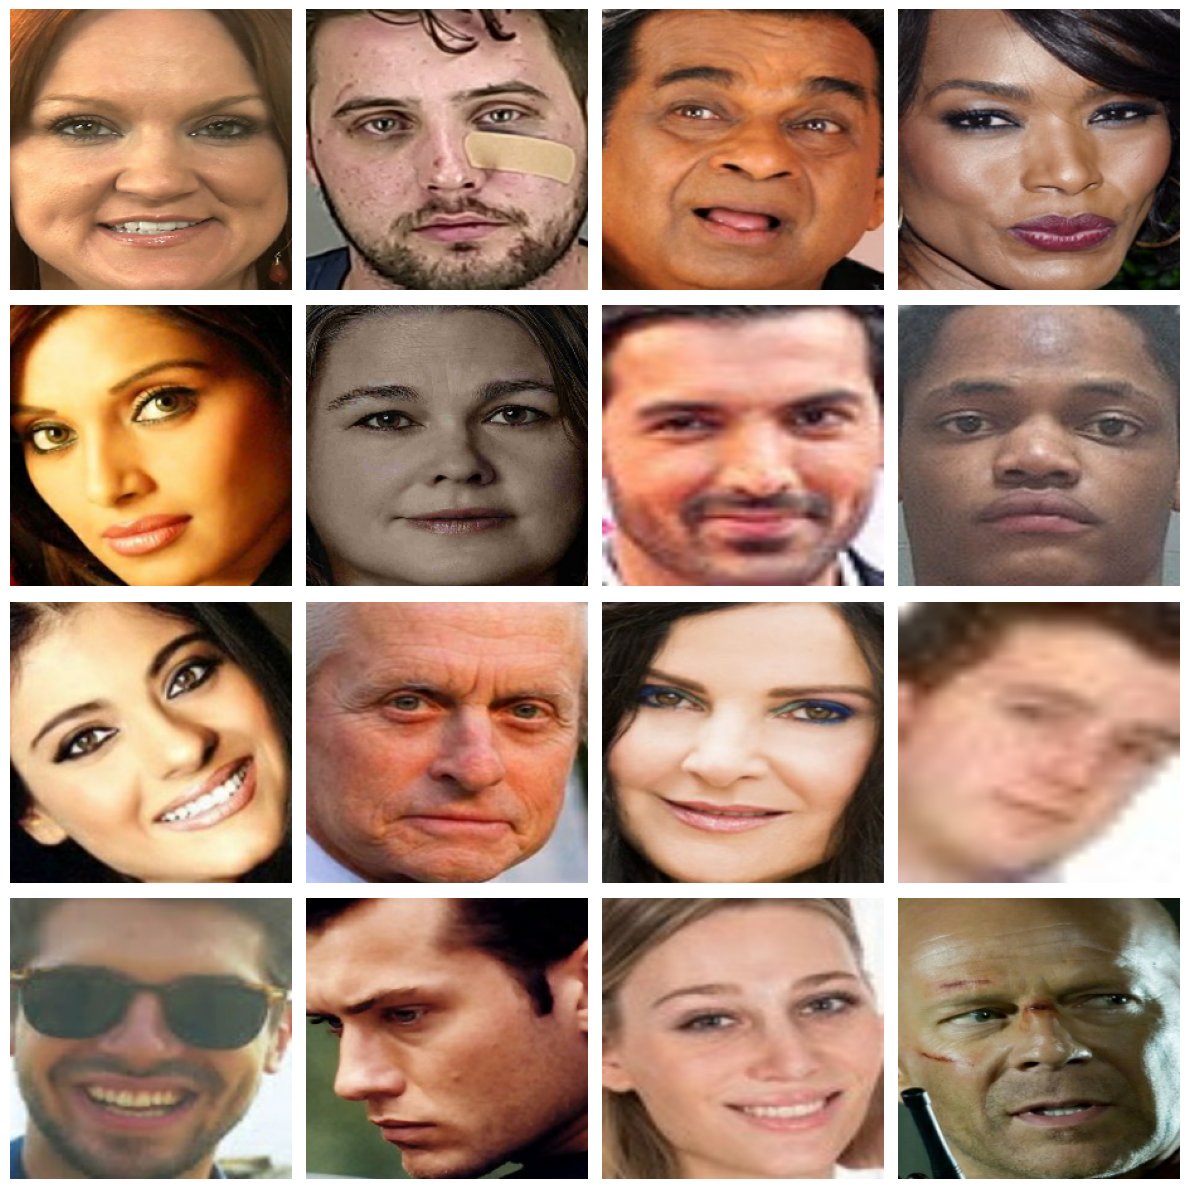

In [27]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

> **Observation:** All 16 images render as clean 224 x 224 colour images, with a mix of faces in different poses, ages and lighting. One image in the grid is visibly blurry, which is a result of upscaling a low-resolution original. No decoding problems are visible.

---
# 5. Data Augmentation

## 5.1 Define the augmentation layers

**What this cell does:** Builds a small `Sequential` block with three random transformations:

| Layer | Setting | Effect |
|---|---|---|
| `RandomFlip` | horizontal | mirrors the image left to right |
| `RandomRotation` | 0.1 | rotates by up to 10% of a full turn (about +/-36 degrees) |
| `RandomZoom` | 0.1 | zooms in or out by up to 10% |

**Why:**
- With only 1,614 training images, a model can easily memorise the data. Augmentation shows it a slightly different version of each image every epoch, which acts as regularisation.
- Only horizontal flips are used because faces in this data are upright, and a vertical flip would create unrealistic inputs.
- As noted in the code comment, augmentation increases the *variety* of what the model sees, not the number of stored samples.
- The block is placed **inside the model** (Section 6). Keras random preprocessing layers are inactive at inference time, so augmentation is applied during training only.

In [28]:
data_augmentation = tf.keras.Sequential([    #Augmentation increases the variety of training data, not necessarily the number of dataset samples.
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

## 5.2 Preview augmented images

**What this cell does:** Passes one training batch through `data_augmentation` and plots 16 results.

**Why:** To confirm the augmentation is realistic and not so strong that it destroys the useful information in the face.

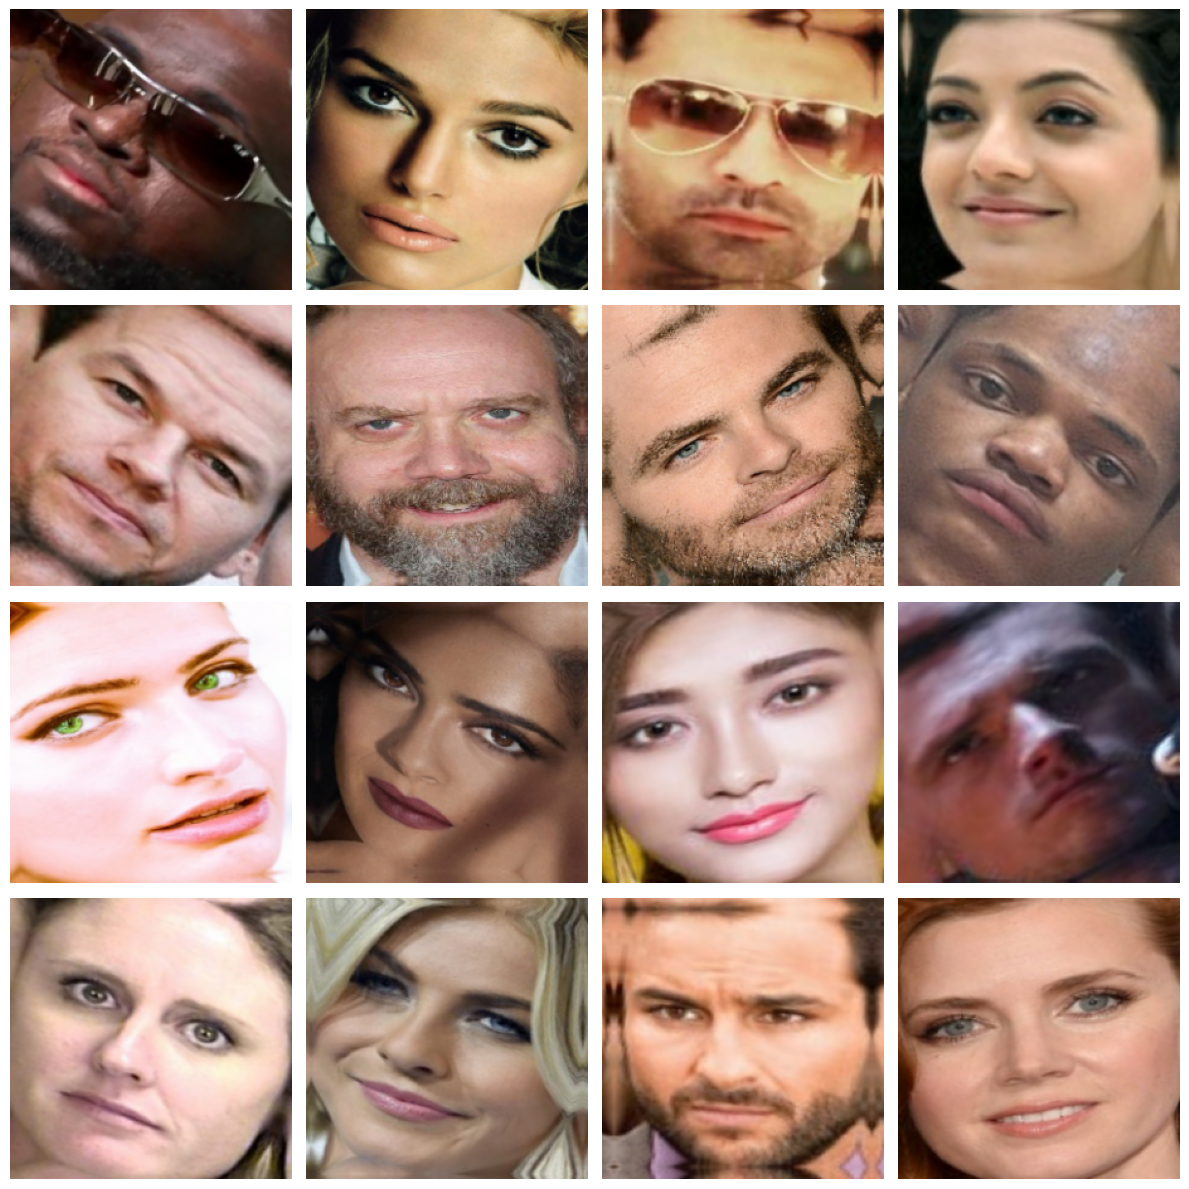

In [29]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

> **Observation:** The grid shows the expected flips, tilts and zoom changes. Areas left empty by rotation or zoom are filled by mirroring the image edges, which is visible at some borders. Faces remain clearly visible in all 16 samples.
>
> **Conclusion:** The augmentation settings are moderate and suitable for this task.

---
# 6. Model Architecture

## 6.1 Load the pre-trained MobileNetV2 backbone

**What this cell does:** Loads MobileNetV2 with ImageNet weights, removes its original classification layer (`include_top=False`) and freezes all backbone weights (`trainable = False`).

**Why:**
- **Transfer learning:** the backbone already knows general visual features (edges, textures, shapes) from ImageNet, so we do not need to learn them from only ~1.6k images.
- **Frozen weights:** only the new head is trained. This means far fewer parameters to fit, faster training and a lower risk of overfitting on a small dataset.
- **MobileNetV2:** a lightweight architecture (about 2.26 million parameters) with fast inference, a good fit for a simple binary task and for possible deployment on limited hardware.

In [30]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


> **Observation:** The ImageNet weights for the no-top variant were downloaded (about 9.4 MB).

## 6.2 Assemble the full model

**What this cell does:** Stacks the layers into one `Sequential` model and prints its summary.

| Layer | Role |
|---|---|
| `Input (224, 224, 3)` | Accepts raw RGB images with pixel values 0-255 |
| `data_augmentation` | Random flip / rotation / zoom, active only during training |
| `Lambda(preprocess_input)` | Rescales pixels to the range MobileNetV2 was trained on ([-1, 1]) |
| `MobileNetV2` (frozen) | Feature extractor, outputs a 7 x 7 x 1280 feature map |
| `GlobalAveragePooling2D` | Averages each feature map into a 1,280-value vector, with far fewer parameters than `Flatten` |
| `Dense(256, relu)` | Learns gender-related combinations of the extracted features |
| `Dropout(0.3)` | Randomly drops 30% of units during training to reduce overfitting |
| `Dense(1, sigmoid)` | Outputs one probability, P(woman) |

**Why a single sigmoid unit:** for two classes, one output between 0 and 1 is enough. Values of 0.5 or above are read as `woman` and values below as `man`.

In [31]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),

    data_augmentation,

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

> **Observation:**
>
> | Parameters | Count | Share |
> |---|---|---|
> | Total | 2,586,177 (9.87 MB) | 100% |
> | Trainable (Dense head) | 328,193 (1.25 MB) | about 12.7% |
> | Non-trainable (frozen MobileNetV2) | 2,257,984 (8.61 MB) | about 87.3% |
>
> The head consists of 327,936 parameters in the 256-unit `Dense` layer and 257 in the output layer.
>
> **Conclusion:** Only about one eighth of the model is trained, which keeps training quick and suits the small dataset.

## 6.3 Compile the model

**What this cell does:** Sets the optimiser, loss and metric.

**Why:**
- **Adam, learning rate 0.001:** a common default and a sensible starting point for training a new classification head.
- **`binary_crossentropy`:** the matching loss for one sigmoid output and 0 / 1 labels.
- **`accuracy`:** appropriate because the classes are balanced (Section 2.3).

In [32]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 6.4 Early stopping callback

**What this cell does:** Watches `val_loss` and stops training if it has not improved for **10 consecutive epochs**. With `restore_best_weights=True` the model is rolled back to the weights from its best epoch.

**Why:** It prevents overfitting and wastes no compute on epochs that no longer help. It also means the epoch count in the next section (40) is only an upper limit.

In [33]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

---
# 7. Training

## 7.1 Train the model

**What this cell does:** Trains for up to 40 epochs on the training set, evaluates on the validation set after every epoch, and applies the early stopping callback. Results are stored in `history`.

In [34]:
history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.8569 - loss: 0.3115 - val_accuracy: 0.9335 - val_loss: 0.1684
Epoch 2/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8978 - loss: 0.2580 - val_accuracy: 0.9393 - val_loss: 0.1537
Epoch 3/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9102 - loss: 0.2141 - val_accuracy: 0.9017 - val_loss: 0.2066
Epoch 4/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9238 - loss: 0.1948 - val_accuracy: 0.9451 - val_loss: 0.1375
Epoch 5/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9257 - loss: 0.1717 - val_accuracy: 0.9249 - val_loss: 0.1705
Epoch 6/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9300 - loss: 0.1633 - val_accuracy: 0.9451 - val_loss: 0.1350
Epoch 7/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9362 - loss: 0.1725 - val_accuracy: 0.9480 - val_loss: 0.1530
Epoch 8/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9195 - loss: 0.1848 - val_a

> **Observation:** Training ran for **19 epochs** and then stopped. The best validation loss occurred at epoch 9, and none of the following 10 epochs beat it, which triggered early stopping. After the first epoch (17 s) each epoch took roughly 5 to 11 seconds.
>
> | Epoch | Train acc | Train loss | Val acc | Val loss |
> |---|---|---|---|---|
> | 1 | 0.8569 | 0.3115 | 0.9335 | 0.1684 |
> | 9 (best) | 0.9343 | 0.1662 | **0.9624** | **0.1056** |
> | 19 (last) | 0.9449 | 0.1429 | 0.9538 | 0.1093 |
>
> - Training accuracy rose from 85.7% to 94.5%, and training loss fell from 0.31 to 0.14.
> - Validation accuracy stayed between 90.2% and 96.2%.
> - Validation accuracy was higher than training accuracy in 16 of 19 epochs, and validation loss was lower than training loss in 18 of 19 epochs. This is common when training metrics are averaged over an epoch with augmentation and dropout switched on, while validation is measured at the end of the epoch with both switched off.
>
> **Conclusion:** The model learns quickly, and the small gap between training and validation metrics shows no sign of overfitting.

## 7.2 Identify the best epoch

**What this cell does:** Finds the epoch with the lowest validation loss and prints its loss and accuracy.

**Why:** It reports which epoch the restored weights come from.

In [35]:

best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best epoch:", best_epoch)
print("Best validation loss:", history.history["val_loss"][best_epoch - 1])
print("Best validation accuracy:", history.history["val_accuracy"][best_epoch - 1])

Best epoch: 9
Best validation loss: 0.10562118142843246
Best validation accuracy: 0.9624277353286743


> **Observation:** Best epoch = **9**, validation loss = **0.1056**, validation accuracy = **96.24%**.
>
> Because `restore_best_weights=True`, the model in memory now holds the epoch-9 weights, and all later evaluation uses them.

## 7.3 Save the trained model

**What these cells do:** Save the model in Keras format (architecture, weights and optimiser state in one file) and print the file size.

**Notes:**
- The file is written to the current working directory of the Colab runtime, which is temporary storage. Copy it to Drive if it needs to be kept.
- The file name says `40_epoch`, which reflects the maximum epoch setting. The training actually ran for 19 epochs.

In [36]:
mobilenet_model.save("40_epoch_genderdetc.keras")

In [37]:
print(os.path.getsize("40_epoch_genderdetc.keras") / (1024 * 1024), "MB")

12.945192337036133 MB


> **Observation:** The saved model file is about **12.95 MB**, small enough for easy sharing and deployment.

## 7.4 Learning curves: accuracy

**What this cell does:** Plots training and validation accuracy for every epoch.

**Why:** Learning curves show how training progressed and whether the model is over- or under-fitting.

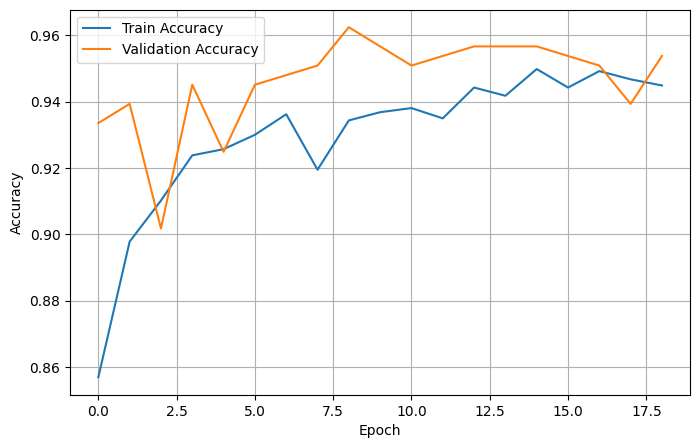

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

> **Observation:** Training accuracy climbs from about 0.86 to about 0.95, with a small dip around epoch 8. Validation accuracy is noisier, with dips near the start and at epoch 18, and peaks at about 0.96. The x-axis starts at 0, so the peak at index 8 is epoch 9.

## 7.5 Learning curves: loss

**What this cell does:** Plots training and validation loss for every epoch.

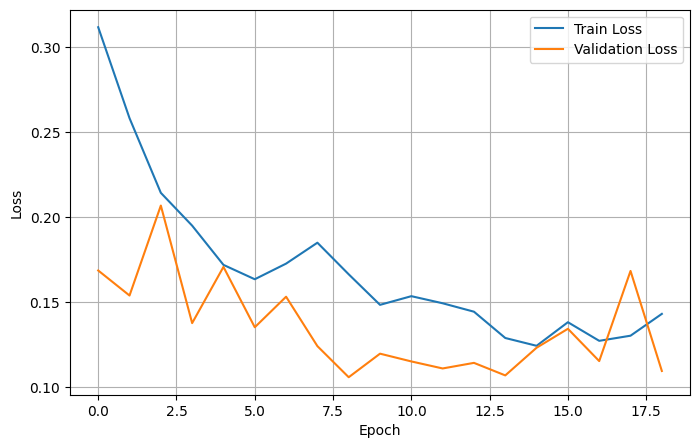

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

> **Observation:** Training loss falls from about 0.31 to about 0.14 overall, with a small bump around epochs 7 to 8. Validation loss stays below training loss for most epochs and reaches its minimum (0.1056) at epoch 9. It has two visible spikes, at epoch 3 (0.2066) and epoch 18 (0.1681).
>
> **Conclusion (learning curves):** The two curves stay close together and validation loss does not trend upward, so the model is not overfitting. The spikes are expected with a validation set of only 346 images, where a single image is worth about 0.29 percentage points of accuracy. Most of the learning happens within the first ~10 epochs, and further training did not improve validation loss.

---
# 8. Evaluation and Error Analysis

## 8.1 Evaluate on the test set

**What this cell does:** Computes loss and accuracy on the test set.

**Why:** The test set was never used for training or for choosing the epoch, so it gives the most honest estimate of performance on unseen images.

In [40]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9481 - loss: 0.1483
Test Loss: 0.1483297049999237
Test Accuracy: 0.9481267929077148


> **Observation:**
>
> | Set | Loss | Accuracy |
> |---|---|---|
> | Validation (best epoch) | 0.1056 | 96.24% |
> | **Test** | **0.1483** | **94.81%** |
>
> **Conclusion:** Test accuracy is about 1.4 percentage points below the best validation accuracy, which is roughly 5 images out of 347. A small drop is expected, because the validation set was used to pick the best epoch and is therefore slightly optimistic. The gap is small, so the model generalises well.

## 8.2 Generate test-set predictions

**What this cell does:** Runs the model on every test batch, converts each sigmoid probability to a class using a **0.5 threshold**, and collects the true and predicted labels in `y_true` and `y_pred`.

**Why:** scikit-learn's metric functions need these two label arrays. This works because the test dataset is not shuffled, so labels and predictions stay in the same order.

In [41]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    # Sigmoid probability → binary class
    predicted_classes = (predictions >= 0.5).astype(int).flatten()
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (347,)
Predicted labels shape: (347,)


> **Observation:** Both arrays contain **347** entries, one per test image.

## 8.3 Class names in label order

**What this cell does:** Rebuilds the list of class names ordered by their numeric label.

**Why:** Used to give readable names to the classification report, confusion matrix and error plots.

In [42]:
class_names = (
    train_df.sort_values("label")
    .drop_duplicates("label")["gender"]
    .tolist()
)

print(len(class_names))
print(class_names)

2
['man', 'woman']


> **Observation:** `['man', 'woman']`, i.e. index 0 is `man` and index 1 is `woman`.

## 8.4 Classification report

**What this cell does:** Prints precision, recall, F1-score and support for each class.

**How to read it:**
- **Precision:** of the images predicted as a class, how many were correct.
- **Recall:** of the images that truly belong to a class, how many were found.
- **F1-score:** the harmonic mean of precision and recall.
- **Support:** the number of test images in that class.

In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         man       0.94      0.96      0.95       176
       woman       0.96      0.94      0.95       171

    accuracy                           0.95       347
   macro avg       0.95      0.95      0.95       347
weighted avg       0.95      0.95      0.95       347



> **Observation:**
>
> | Class | Precision | Recall | F1-score | Support |
> |---|---|---|---|---|
> | man | 0.94 | 0.96 | 0.95 | 176 |
> | woman | 0.96 | 0.94 | 0.95 | 171 |
> | **Accuracy** | | | **0.95** | 347 |
> | Macro avg | 0.95 | 0.95 | 0.95 | 347 |
>
> **Conclusion:** Performance is well balanced across both classes (F1 of 0.95 each). `man` has slightly higher recall and `woman` slightly higher precision, which is the same trade-off seen in the confusion matrix below. The test set itself is nearly balanced (176 vs 171).

## 8.5 Confusion matrix

**What this cell does:** Plots the confusion matrix as an annotated heatmap.

**Why:** It shows exactly which mistakes the model makes, not just how many.

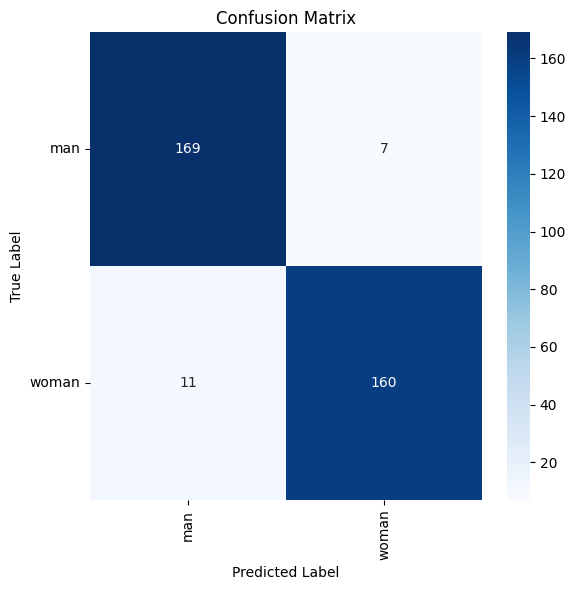

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d"          # Show numbers as integers
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

> **Observation:**
>
> | | Predicted man | Predicted woman |
> |---|---|---|
> | **Actual man** | 169 | 7 |
> | **Actual woman** | 11 | 160 |
>
> **Conclusion:** 329 of 347 images are correct (169 + 160), which matches the 94.81% test accuracy. Errors are spread over both classes, and the diagonal dominates.

## 8.6 Most confused class pairs

**What this cell does:** Zeroes out the diagonal of the confusion matrix and lists the off-diagonal entries from largest to smallest.

**Why:** It ranks the most common misclassification types. With two classes there are only two of them, but the same code works unchanged for more classes.

In [45]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

indices = np.argsort(cm_no_diag.ravel())[::-1]

for idx in indices:
    true_class, pred_class = np.unravel_index(idx, cm.shape)

    # Skip correct predictions
    if true_class == pred_class:
        continue

    print(
        f"{class_names[true_class]} → {class_names[pred_class]} : "
        f"{cm[true_class, pred_class]} images"
    )

woman → man : 11 images
man → woman : 7 images


> **Observation:**
>
> | True class | Predicted as | Images | Share of that class |
> |---|---|---|---|
> | woman | man | 11 | 6.4% (11 / 171) |
> | man | woman | 7 | 4.0% (7 / 176) |
>
> **Note:** The model makes more errors on `woman` than on `man`, but the difference is only 4 images out of 347. That is not enough evidence to claim a systematic bias. It would need a larger test set or repeated splits to confirm.

## 8.7 Collect test images and predictions for error analysis

**What this cell does:** Gathers all test images and labels into NumPy arrays and predicts on them again, so individual misclassified images can be looked up by index.

**Why:** The batched pipeline is not convenient for picking out single images. Because the model has no augmentation at inference time, these predictions match those from Section 8.2.

In [46]:
test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

predictions = mobilenet_model.predict(test_images, verbose=0)

# Sigmoid probability → binary class
pred_labels = (predictions >= 0.5).astype(int).flatten()

## 8.8 Inspect misclassified images

**What this cell does:** Finds every test image where the prediction differs from the true label, prints the total, and plots the first 16 with their true and predicted labels.

**Why:** Looking at real mistakes often shows what the model finds difficult and what to improve next.

Total wrong predictions: 18


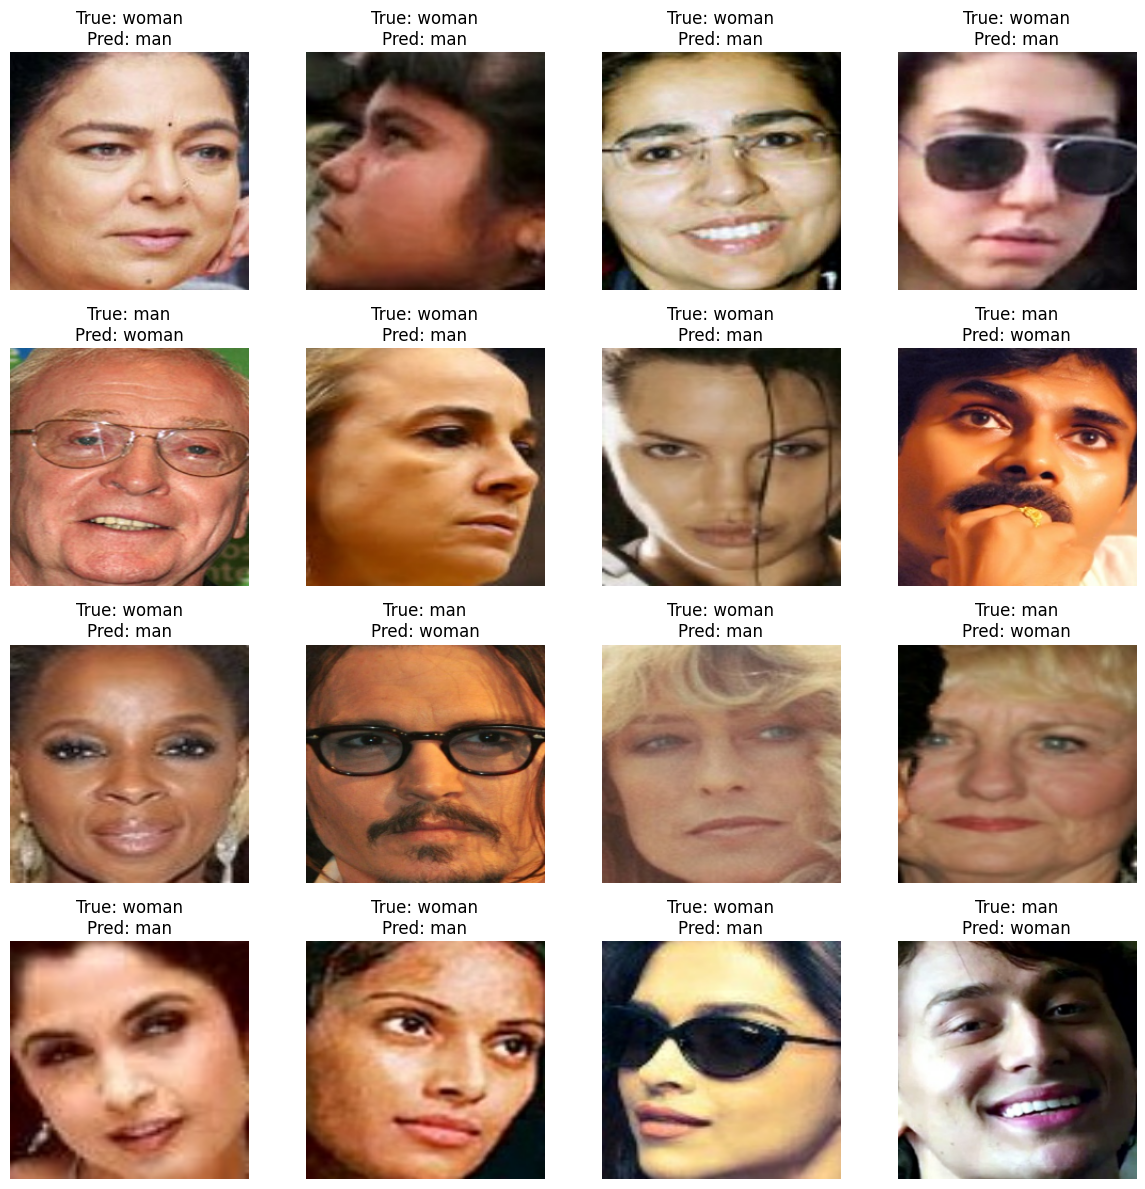

In [47]:
wrong_indices = np.where(test_labels != pred_labels)[0]

print("Total wrong predictions:", len(wrong_indices))

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_indices[:16]):
    plt.subplot(4, 4, i + 1)

    plt.imshow(test_images[idx].astype("uint8"))

    true_name = class_names[test_labels[idx]]
    pred_name = class_names[pred_labels[idx]]

    plt.title(f"True: {true_name}\nPred: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

> **Observation:** There are **18 wrong predictions** out of 347 (5.2%), which agrees with the confusion matrix (7 + 11) and with the 94.81% accuracy. The grid shows the first 16 of them, and mistakes in both directions appear.
>
> Across the displayed samples several recurring conditions can be seen:
> - sunglasses or eyeglasses,
> - heads turned to the side or partly covered by hair or a hand,
> - heavy make-up or strong lighting and colour casts,
> - older faces and tight crops.
>
> **Interpretation:** These are qualitative observations from 16 images, and the notebook does not measure how often each condition occurs. A reasonable hypothesis is that occlusion, non-frontal pose and unusual lighting hide the visual cues the model relies on. This is worth testing in future work (see Section 10).

---
# 9. Single Image Inference

## 9.1 Prediction helper function

**What this cell does:** Defines `predict_gender(image_path)`, which:
1. reads and decodes the image (`decode_image` handles common formats, and `expand_animations=False` guarantees a 3-D tensor),
2. resizes it to 224 x 224 and casts to `float32`,
3. adds a batch dimension, giving shape (1, 224, 224, 3),
4. gets the sigmoid probability from the model,
5. applies the 0.5 threshold to pick the class,
6. reports the **confidence of the predicted class** (the probability itself for `woman`, and 1 minus the probability for `man`),
7. shows the image with the result as its title, and returns the class and confidence.

**Why:** It shows how the trained model would be used on a new image. No manual normalisation is needed, because scaling is already part of the model (Section 6.2).

In [48]:
def predict_gender(image_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # (224, 224, 3) → (1, 224, 224, 3)
    image_batch = tf.expand_dims(image, axis=0)

    # Sigmoid output
    prediction = mobilenet_model.predict(image_batch, verbose=0)[0][0]

    # Convert probability to class
    predicted_index = 1 if prediction >= 0.5 else 0

    # Confidence of predicted class
    confidence = prediction if predicted_index == 1 else 1 - prediction
    confidence *= 100

    predicted_class = class_names[predicted_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(image.numpy().astype("uint8"))

    plt.title(
        f"Class: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

    return predicted_class, confidence

## 9.2 Run a prediction

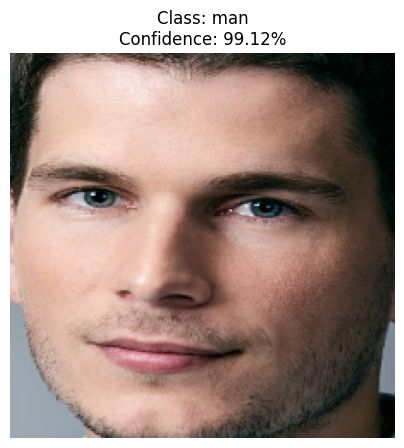

Predicted Class: man
Confidence: 99.12%


In [50]:
image_path = "/content/genderdetc_dataset/Data/gender_dataset_face/man/face_17.jpg"

gender, confidence = predict_gender(image_path)

print("Predicted Class:", gender)
print(f"Confidence: {confidence:.2f}%")

> **Observation:** For `face_17.jpg` from the `man` folder, the model predicts **man** with **99.12%** confidence.
>
> **Note:** This image comes from the dataset folder, and the notebook does not check which split it belongs to, so this is a demonstration of the function and not evidence of model performance. The test-set metrics in Section 8 are the proper performance measure.

---
# 10. Conclusion, Limitations and Future Work

## 10.1 Summary

A binary gender classifier was built on 2,307 face images using **MobileNetV2 transfer learning** with a small trainable head (328,193 of 2,586,177 parameters). The data was checked for balance and corrupted files, split with stratification, loaded through a `tf.data` pipeline, and augmented during training. Early stopping ended training after 19 epochs and restored the epoch-9 weights.

| Set | Loss | Accuracy |
|---|---|---|
| Validation (best epoch) | 0.1056 | 96.24% |
| **Test** | **0.1483** | **94.81%** |

## 10.2 Key findings

- The dataset is clean and effectively balanced, so accuracy is a fair metric and no rebalancing was needed.
- A frozen pre-trained backbone reaches **94.81% test accuracy** while training only about 12.7% of the parameters.
- The model converges quickly (best validation loss at epoch 9), and training and validation curves stay close, with no sign of overfitting.
- Precision, recall and F1 are all about 0.95 for both classes. There are 18 errors in 347 test images: 11 `woman` predicted as `man` and 7 `man` predicted as `woman`.
- In the misclassified samples that were displayed, glasses, non-frontal poses, hair or hand occlusion, heavy make-up and unusual lighting appear frequently.

## 10.3 Limitations

- **Small data and a single split:** 2,307 images, one random train / validation / test split, no cross-validation. With 347 test images, one image equals about 0.29 percentage points, so the reported accuracy carries some uncertainty.
- **Dataset scope is not analysed:** the notebook does not examine how the labels were produced or the age, skin-tone or ethnic composition of the images. Performance across such subgroups is therefore unknown.
- **Binary labels only:** the model predicts one of two classes as labelled in the dataset.
- **No fine-tuning:** the backbone stayed frozen for the whole run.
- **Error analysis is qualitative:** only 16 of the 18 errors were viewed, and the patterns noted were not counted.
